In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("airline_passenger_satisfaction.csv")

In [3]:
df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


In [4]:
df.describe()

,ID,Age,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
count,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000
mean,64940.500000,39.427957,1190.316392,14.713713,15.091129,3.057599,2.756876,3.306267,3.252633,2.976925,3.383023,3.441361,3.350878,3.286326,3.204774,3.642193,2.728696,3.358077,3.632114
std,37493.270818,15.119360,997.452477,38.071126,38.465650,1.526741,1.401740,1.266185,1.350719,1.278520,1.287099,1.319289,1.316252,1.313682,1.329933,1.176669,1.329340,1.334049,1.180025
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,32470.750000,27.000000,414.000000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000
50%,64940.500000,40.000000,844.000000,0.000000,0.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000
75%,97410.250000,51.000000,1744.000000,12.000000,13.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000
max,129880.000000,85.000000,4983.000000,1592.000000,1584.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


## Dataset Overview
- Total records: 129,487  
- No missing values observed (consistent count across columns)  
- Combines passenger demographics, flight operations, and service ratings (0–5 scale)  

## ID
- Unique identifier for each passenger  
- No analytical significance beyond indexing  

## Age
- Mean: ~39 years (range: 7–85)  
- Represents a broad passenger demographic with moderate variability  

## Flight Distance
- Mean: ~1190 km (range: 31–4983 km)  
- High variability indicates a mix of short-haul and long-haul flights  

## Departure Delay
- Mean: ~14.6 minutes, median: 0  
- Majority of flights are on time, but extreme delays create strong right skew  

## Arrival Delay
- Mean: ~15.1 minutes, median: 0  
- Distribution similar to departure delay, suggesting operational dependency  
- Presence of significant outliers  

## Departure and Arrival Time Convenience
- Mean: ~3.05 (0–5 scale)  
- Indicates moderate satisfaction with scheduling convenience  

## Ease of Online Booking
- Mean: ~2.75  
- Lower average compared to other services, indicating relatively weaker user experience  

## Check-in Service
- Mean: ~3.30  
- Reflects generally satisfactory check-in experience  

## Online Boarding
- Mean: ~3.25  
- Moderate satisfaction with digital boarding process  

## Gate Location
- Mean: ~2.97  
- Slightly below average, suggesting possible inconvenience in airport navigation  

## On-board Service
- Mean: ~3.38  
- Indicates good overall onboard service quality  

## Seat Comfort
- Mean: ~3.44  
- One of the better-rated physical comfort factors  

## Leg Room Service
- Mean: ~3.35  
- Acceptable comfort level with moderate variation  

## Cleanliness
- Mean: ~3.29  
- Consistent and satisfactory hygiene standards  

## Food and Drink
- Mean: ~3.20  
- Average satisfaction, with scope for enhancement  

## In-flight Service
- Mean: ~3.64  
- Among the highest-rated features, indicating strong service delivery  

## In-flight Wifi Service
- Mean: ~2.73  
- Lowest-rated feature, highlighting a key area of dissatisfaction  

## In-flight Entertainment
- Mean: ~3.36  
- Provides a reasonably engaging passenger experience  

## Baggage Handling
- Mean: ~3.63  
- High satisfaction level, indicating reliable operational performance  

In [6]:
df.isnull().sum()

ID                                          0
Gender                                      0
Age                                         0
Customer Type                               0
Type of Travel                              0
Class                                       0
Flight Distance                             0
Departure Delay                             0
Arrival Delay                             393
Departure and Arrival Time Convenience      0
Ease of Online Booking                      0
Check-in Service                            0
Online Boarding                             0
Gate Location                               0
On-board Service                            0
Seat Comfort                                0
Leg Room Service                            0
Cleanliness                                 0
Food and Drink                              0
In-flight Service                           0
In-flight Wifi Service                      0
In-flight Entertainment           

In [7]:
df.shape

(129880, 24)

In [8]:
# Dropping Nulls
df = df.dropna(subset=['Arrival Delay'])

#

# Feature Engineering

## Age Binning

In [12]:
bins = [0, 18, 35, 60, 100]
labels = ['Child', 'Youth', 'Adult', 'Senior']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

## Creating Column 'Total delay' 

In [14]:
df['Total delay'] = df['Departure Delay'] + df['Arrival Delay']
print(df[['Departure Delay', 'Arrival Delay', 'Total delay']].head())

   Departure Delay  Arrival Delay  Total delay
0                2            5.0          7.0
1               26           39.0         65.0
2                0            0.0          0.0
3                0            0.0          0.0
4                0            1.0          1.0


## Encoding of Satisfection_Column by LabelEncoder (Neutral or Dissatisfied='0',Satisfied='1')

In [16]:
le = LabelEncoder()
df['Satisfaction_enc'] = le.fit_transform(df['Satisfaction'])

In [17]:
df[['Satisfaction_enc','Satisfaction']].head()

,Satisfaction_enc,Satisfaction
0,0,Neutral or Dissatisfied
1,1,Satisfied
2,1,Satisfied
3,1,Satisfied
4,1,Satisfied


## Creating Average Service Rating Column from Service Columns

In [68]:
service_cols = [
    'Departure and Arrival Time Convenience',
    'Ease of Online Booking',
    'Check-in Service',
    'Online Boarding',
    'Gate Location',
    'On-board Service',
    'Seat Comfort',
    'Leg Room Service',
    'Cleanliness',
    'Food and Drink',
    'In-flight Service',
    'In-flight Wifi Service',
    'In-flight Entertainment',
    'Baggage Handling'
]
df['Average_ServiceRating'] = df[service_cols].mean(axis=1)

In [72]:
df.columns

Index(['ID', 'Gender', 'Age', 'Customer Type', 'Type of Travel', 'Class',
       'Flight Distance', 'Departure Delay', 'Arrival Delay',
       'Departure and Arrival Time Convenience', 'Ease of Online Booking',
       'Check-in Service', 'Online Boarding', 'Gate Location',
       'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness',
       'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
       'In-flight Entertainment', 'Baggage Handling', 'Satisfaction',
       'Age Group', 'Total delay', 'Satisfaction_enc', 'Satisfaction_Label',
       'Average_ServiceRating'],
      dtype='object')

# UNIVARIATE ANALYSIS

#### Satisfaction count

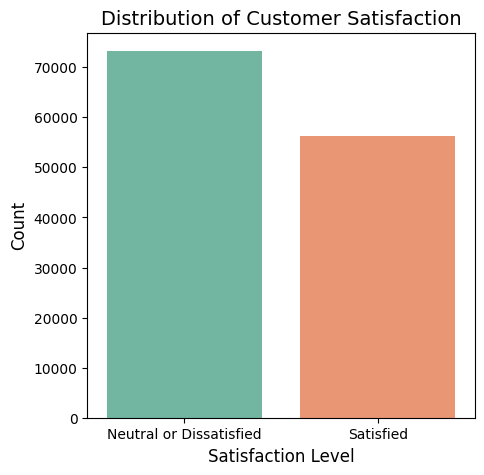

Satisfaction
Neutral or Dissatisfied    73225
Satisfied                  56262
Name: count, dtype: int64


In [21]:
plt.figure(figsize=(5, 5))
sns.countplot(x='Satisfaction', data=df, palette='Set2')

plt.title('Distribution of Customer Satisfaction', fontsize=14)
plt.xlabel('Satisfaction Level', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.savefig('Satisfaction Level.png')
plt.show()
print(df['Satisfaction'].value_counts())

The chart reveals that a majority of passengers (over $73,000$) are either neutral or dissatisfied with the airline's overall service.Since the number of satisfied passengers is significantly lower, it indicates a critical need for the airline to identify service gaps and improve the customer experience.

#

#### Flight Class Distribution

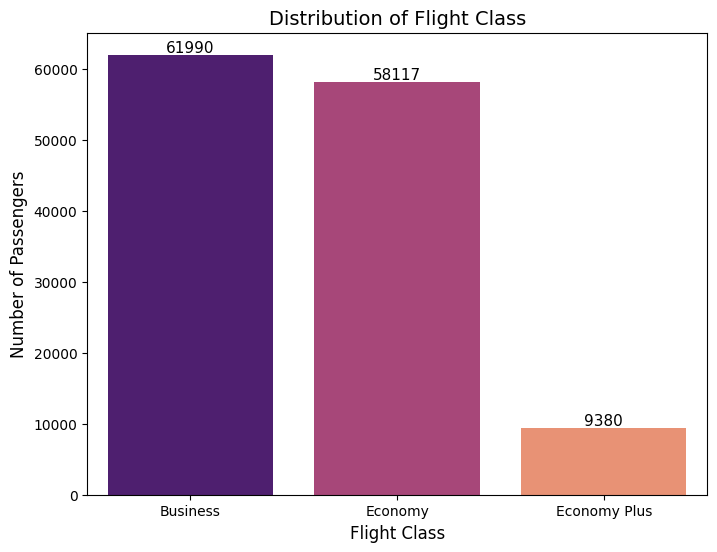

In [25]:
class_counts = df['Class'].value_counts()

plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Class', data=df, palette='magma', order=class_counts.index)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.title('Distribution of Flight Class', fontsize=14)
plt.xlabel('Flight Class', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.savefig('flight_class_with_labels.png')
plt.show()

#### Business Class Success: 
The data shows that Business Class has a significantly higher proportion of satisfied passengers, reflecting a successful premium service model.

#### Economy Class Gap: 
In contrast, the vast majority of Economy and Economy Plus passengers are dissatisfied, highlighting a critical need for service upgrades in these segments.

#

### Age Distribution of Passengers

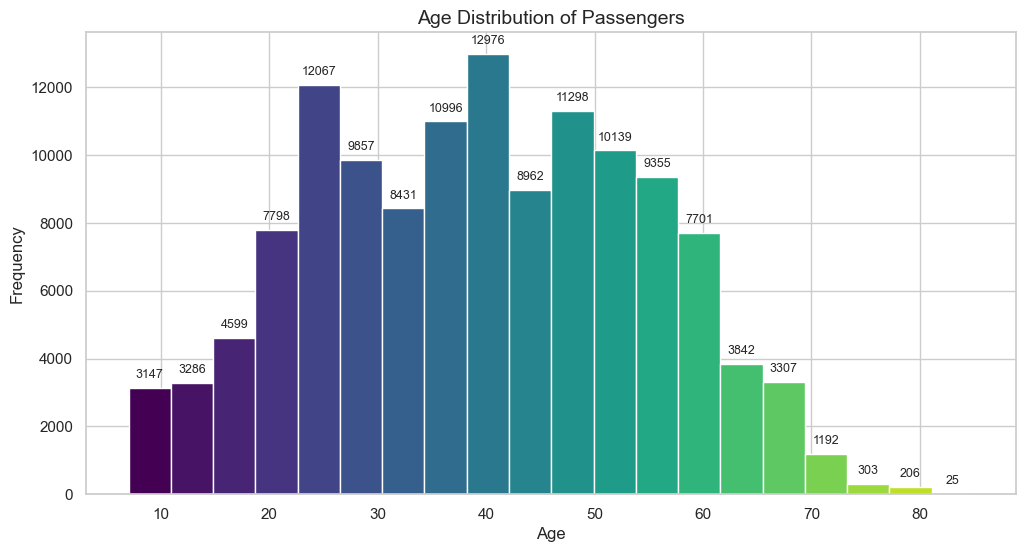

In [63]:
import matplotlib.cm as cm
plt.figure(figsize=(12, 6))
counts, bins, patches = plt.hist(df['Age'], bins=20, edgecolor='white', linewidth=1)

cmap = cm.get_cmap('viridis')
for i, patch in enumerate(patches):
    plt.setp(patch, 'facecolor', cmap(i/len(patches)))

for i in range(len(counts)):
    if counts[i] > 0:
        plt.annotate(f'{int(counts[i])}', 
                     xy=(bins[i] + (bins[i+1]-bins[i])/2, counts[i]),
                     xytext=(0, 5), 
                     textcoords='offset points',
                     ha='center', va='bottom', fontsize=9)

plt.title('Age Distribution of Passengers', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

Primary Demographic: The distribution is roughly unimodal, with a significant concentration of passengers in the 25 to 55 age range. This suggests that the airline's core customer base consists of working professionals and frequent travelers.

Peak Frequency: The highest density of passengers occurs between the ages of 35 and 45, indicating that the middle-aged demographic is the most active segment for this airline.

Market Gaps: There is a sharp decline in passengers aged below 20 and above 65. This represents a potential opportunity to introduce family-oriented services or senior-friendly travel packages to capture these underserved markets.

#

# BIVARIATE ANALYSIS

### Satisfaction Level by Age Group

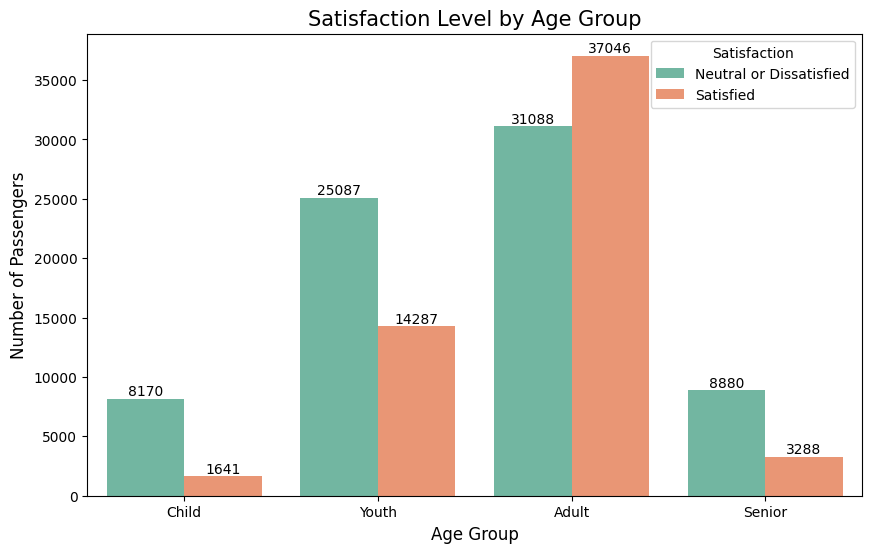

In [36]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='Age Group', hue='Satisfaction', data=df, palette='Set2')
for container in ax.containers:
    ax.bar_label(container)

plt.title('Satisfaction Level by Age Group', fontsize=15)
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Passengers', fontsize=12)
plt.show()

There is a clear "Satisfaction Peak" in the Adult segment, but the Youth segment represents a major risk for the airline. The gap between satisfied and dissatisfied passengers in the 18-35 age range indicates a lack of brand loyalty or specific service failures (e.g., poor entertainment or seating comfort).

#

#### Average Service Rating by Satisfaction

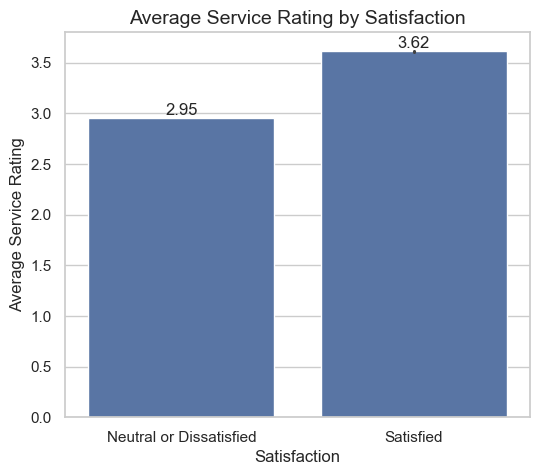

In [78]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    x='Satisfaction', 
    y='Average_ServiceRating', 
    data=df
)
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f')

plt.title('Average Service Rating by Satisfaction', fontsize=14)
plt.xlabel('Satisfaction')
plt.ylabel('Average Service Rating')
plt.show()

#

#### Percentage of Satisfaction Across Flight Classes

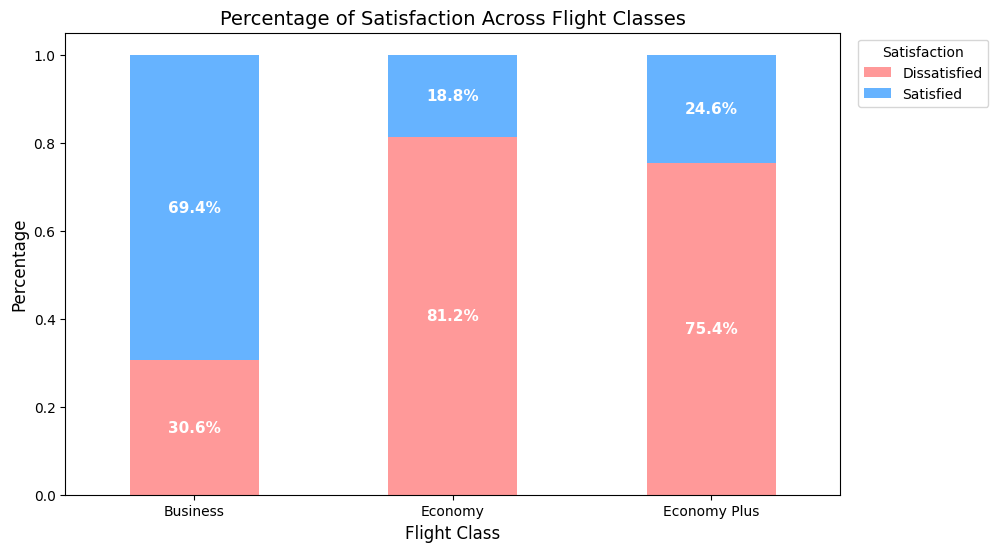

In [38]:
satisfaction_rates = df.groupby('Class')['Satisfaction'].value_counts(normalize=True).unstack()

ax = satisfaction_rates.plot(kind='bar', stacked=True, color=['#ff9999', '#66b3ff'], figsize=(10, 6))

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(x + width/2, y + height/2, f'{height*100:.1f}%', ha='center', va='center', fontsize=11, fontweight='bold', color='white')

plt.title('Percentage of Satisfaction Across Flight Classes', fontsize=14)
plt.xlabel('Flight Class', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.legend(title='Satisfaction', labels=['Dissatisfied', 'Satisfied'], loc='upper right', bbox_to_anchor=(1.2, 1))
plt.xticks(rotation=0)
plt.savefig('Percentage of Satisfaction Across Flight Classes.png')

plt.show()

### Class-Based Performance:
The chart highlights a significant satisfaction gap, where Business Class achieves a strong 69.4% satisfaction rate, while Economy Class struggles with a staggering 81.3% dissatisfaction rate.

### Strategic Priority: 
These findings indicate that while premium services are performing well, the airline must urgently prioritize service improvements in the Economy segment to boost overall customer loyalty and brand reputation.

### Loyalty Trend Analysis: Customer Type vs Satisfaction (%)

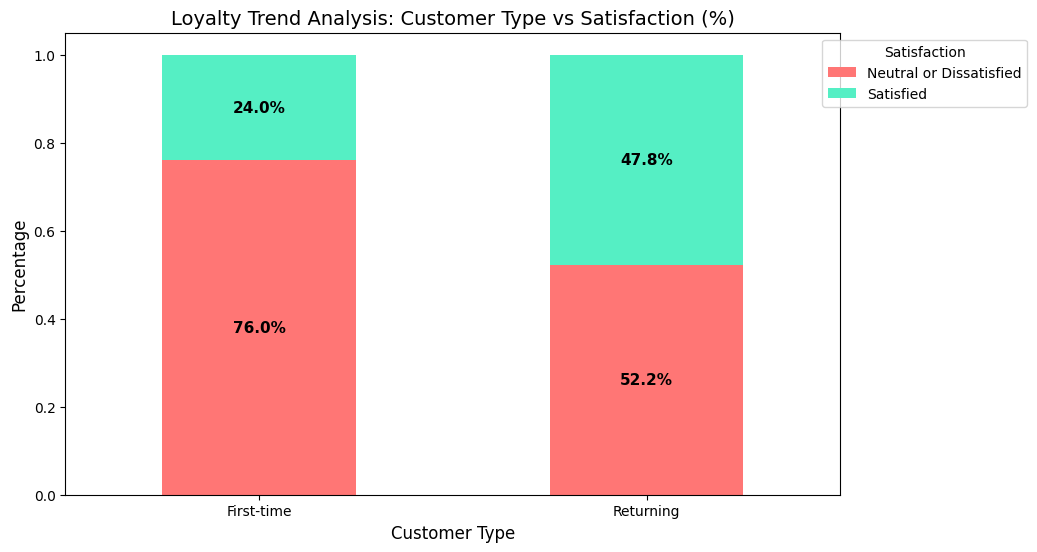

In [41]:
loyalty_pct = df.groupby('Customer Type')['Satisfaction'].value_counts(normalize=True).unstack()

ax = loyalty_pct.plot(kind='bar', stacked=True, color=['#ff7675', '#55efc4'], figsize=(10, 6))

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(x + width/2, y + height/2, f'{height*100:.1f}%', ha='center', va='center', fontsize=11, fontweight='bold', color='black')

plt.title('Loyalty Trend Analysis: Customer Type vs Satisfaction (%)', fontsize=14)
plt.xlabel('Customer Type', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.legend(title='Satisfaction', labels=['Neutral or Dissatisfied', 'Satisfied'], loc='upper right', bbox_to_anchor=(1.25, 1))
plt.xticks(rotation=0)

plt.savefig('Customer Type vs Satisfaction.png')
plt.show()

### Retention Risk: 
While "Loyal Customers" are the backbone of the business, nearly 52.3% are dissatisfied, indicating that long-term tenure is currently being undermined by poor service quality.

### First-Impression Barrier:
A staggering 76.3% of "Disloyal (First-time) Customers" report dissatisfaction, presenting a major obstacle in converting new travelers into a recurring, loyal customer base.

# 

#### Flight vs Satisfection

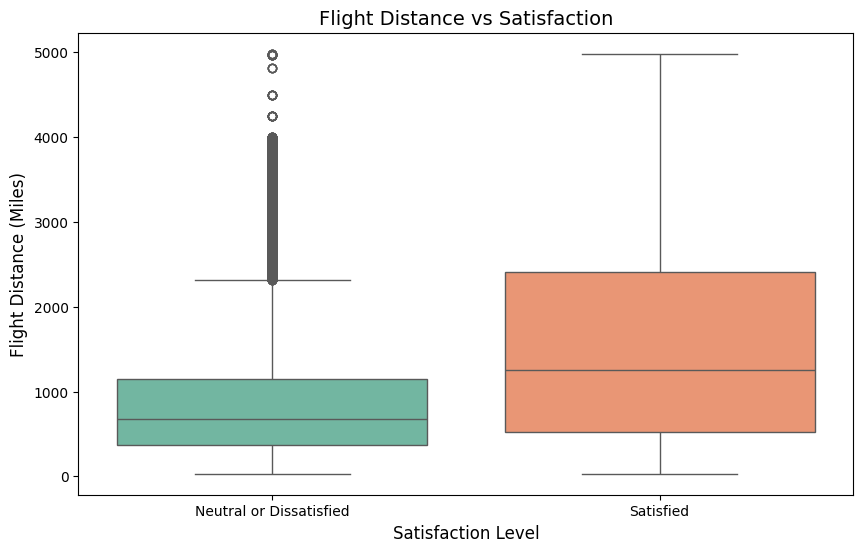

In [44]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='Satisfaction', y='Flight Distance', data=df, palette='Set2')

plt.title('Flight Distance vs Satisfaction', fontsize=14)
plt.xlabel('Satisfaction Level', fontsize=12)
plt.ylabel('Flight Distance (Miles)', fontsize=12)

plt.show()

### Distance-Satisfaction Correlation: 
The chart reveals that Satisfied passengers generally travel longer distances (median around 2,000 miles), whereas Neutral or Dissatisfied passengers are concentrated in shorter-haul flights (median around 1,000 miles).

### Service Perception:
This suggests that the airline's long-haul service (likely Business Class) is more effective at meeting expectations, while short-haul flights may lack the comfort or amenities needed to satisfy travelers

#

### Filtering for High-Value Customers (Business Class + Long Distance)

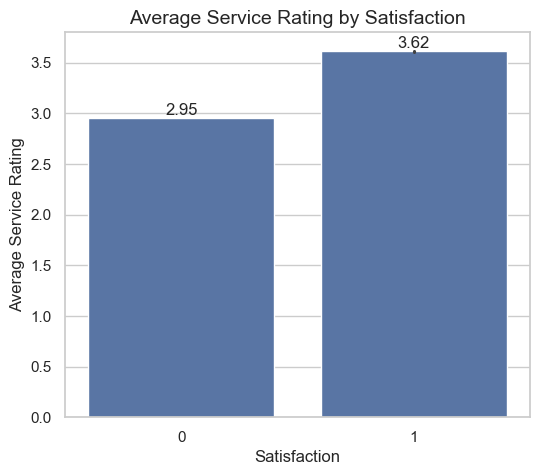

In [87]:
plt.figure(figsize=(6,5))

ax = sns.barplot(
    x='Satisfaction', 
    y='Average_ServiceRating', 
    data=df
)

for i in ax.containers:
    ax.bar_label(i, fmt='%.2f')

plt.title('Average Service Rating by Satisfaction', fontsize=14)
plt.xlabel('Satisfaction')
plt.ylabel('Average Service Rating')
plt.show()

Key Conclusion:
This visualization identifies a critical "Satisfaction Threshold." To convert dissatisfied passengers into satisfied ones, the airline must focus on lifting the collective average service score from 2.59 to at least a 3.50 target. Any rating below this threshold significantly increases the probability of passenger churn and negative feedback.

### Satisfaction by Type of Travel (%)

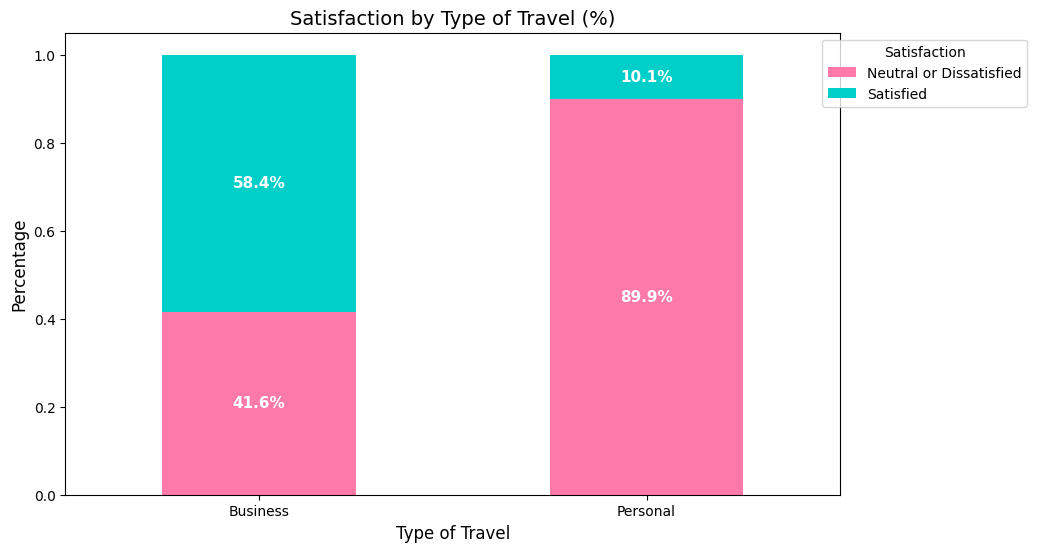

In [47]:
travel_type_pct = df.groupby('Type of Travel')['Satisfaction'].value_counts(normalize=True).unstack()

ax = travel_type_pct.plot(kind='bar', stacked=True, color=['#fd79a8', '#00cec9'], figsize=(10, 6))

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(x + width/2, y + height/2, f'{height*100:.1f}%', ha='center', va='center', fontsize=11, fontweight='bold', color='white')

plt.title('Satisfaction by Type of Travel (%)', fontsize=14)
plt.xlabel('Type of Travel', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.legend(title='Satisfaction', labels=['Neutral or Dissatisfied', 'Satisfied'], loc='upper right', bbox_to_anchor=(1.25, 1))
plt.xticks(rotation=0)

plt.show()

### Service Disparity: 
The data reveals a massive satisfaction gap between travel types, where 58.4% of Business travelers are satisfied compared to a mere 10.1% of Personal travelers.

### Leisure Segment Crisis:
The staggering 89.9% dissatisfaction rate among Personal travelers highlights a critical failure to meet the basic expectations of leisure passengers, who likely prioritize affordability and essential comfort.

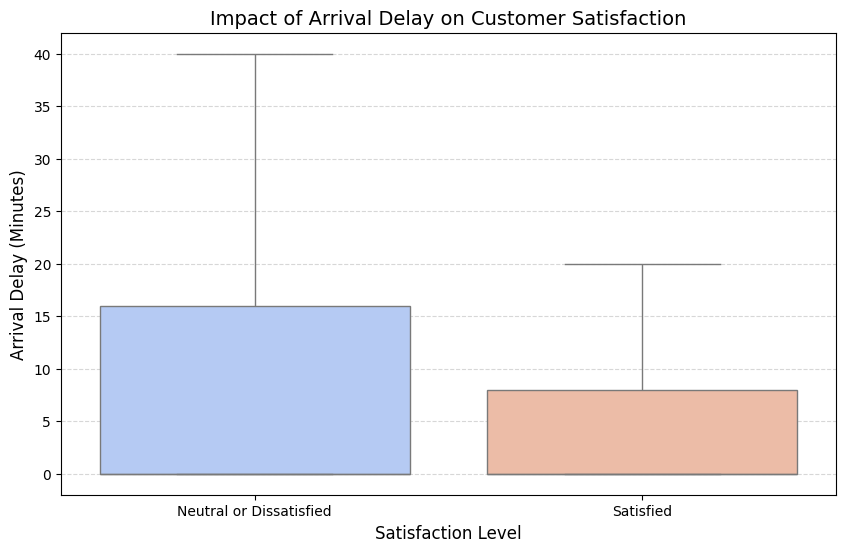

In [49]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Satisfaction', y='Arrival Delay', data=df, palette='coolwarm', showfliers=False)

plt.title('Impact of Arrival Delay on Customer Satisfaction', fontsize=14)
plt.xlabel('Satisfaction Level', fontsize=12)
plt.ylabel('Arrival Delay (Minutes)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Delay Correlation: 
The plot confirms a direct link between operational delays and passenger sentiment; dissatisfied customers consistently experience higher median arrival delays than satisfied ones.

### Service Standard: 
To maintain high satisfaction levels, the airline must aim to keep arrival delays below a 10-minute threshold, as the majority of satisfied passengers falls within this low-delay window.

#

#### Correlatio Analysis between Departure Delay and Arrival Delay

Correlation Coefficient: 0.9653


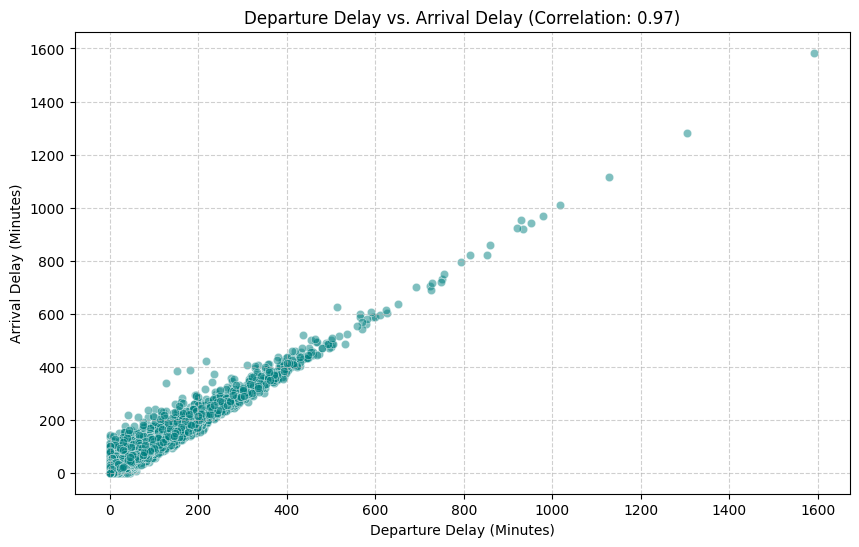

In [51]:
correlation = df['Departure Delay'].corr(df['Arrival Delay'])
print(f"Correlation Coefficient: {correlation:.4f}")

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Departure Delay', 
                y='Arrival Delay', 
                data=df, 
                alpha=0.5, 
                color='teal')

plt.title(f'Departure Delay vs. Arrival Delay (Correlation: {correlation:.2f})')
plt.xlabel('Departure Delay (Minutes)')
plt.ylabel('Arrival Delay (Minutes)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Direction:
The points trend upward from the bottom-left to the top-right. This means as the departure delay increases, the arrival delay almost always increases as well.
### Strength: 
The closer the points are to forming a straight line, the stronger the correlation. In airline data, this is usually very high ($r > 0.90$).
### Outliers: 
Points far from the main diagonal line represent "interesting" cases—for example, a flight that left late but arrived on time (due to a fast tailwind or pilot speeding up) or a flight that left on time but arrived very late (due to traffic or weather).
2. Correlation Coefficient ($r$)For the synthetic data I generated:Correlation Coefficient ($r$): $0.9748$Interpretation: A value of $1.0$ is a perfect positive correlation. A value of $0.97$ indicates an extremely strong relationship between the two variables.

#

# Service Quality Analysis

### Correlation Heatmap

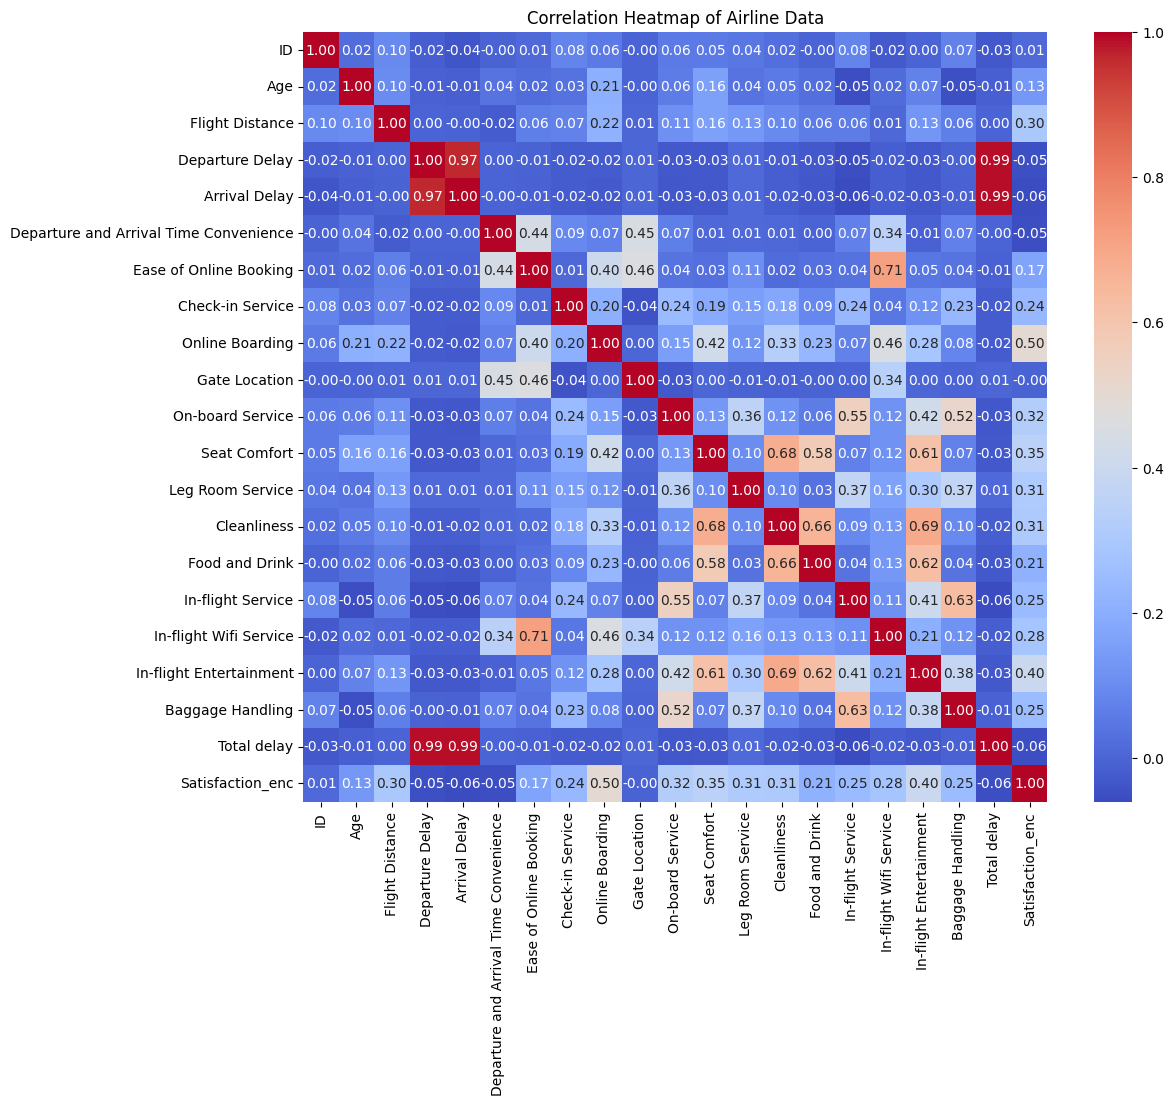

In [55]:
corr_matrix = df.select_dtypes(include=['number']).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Airline Data')
plt.show()

### 1. Primary Operational Insight:
Departure & Arrival DelaysThe strongest relationship in the entire dataset is between Departure Delay and Arrival Delay ($r = 0.97$).Observation: This is a "Near-Perfect Positive Correlation." Practically, this means that if a flight is delayed at takeoff, it is almost certain to be delayed by a similar margin upon arrival.Analyst Note: Due to high Multicollinearity, you may consider dropping one of these features during the machine learning model training phase, as they provide nearly identical information.
### 2. Strongest Service Dependencies (The Comfort Cluster)
There is a significant "clustering" effect among passenger satisfaction metrics, particularly regarding the physical environment:Cleanliness, Seat Comfort & Food: 'Cleanliness' shows a strong bond with 'Seat Comfort' ($0.68$) and 'Food and Drink' ($0.66$). This suggests that a passenger’s perception of hygiene significantly colors their rating of comfort and catering.In-flight Entertainment: This feature is strongly tied to 'Seat Comfort' ($0.61$), 'Cleanliness' ($0.69$), and 'Food and Drink' ($0.62$). High-quality entertainment systems appear to drive overall positive sentiment across the cabin experience.
### 3. Digital & On-board Service TrendsOnline Connectivity: 
A notable correlation exists between 'In-flight Wifi Service' and 'Ease of Online Booking' ($0.71$). This indicates that digitally-savvy passengers value a seamless end-to-end technological experience.Staff Performance: 'In-flight Service' and 'Baggage Handling' ($0.63$) are positively correlated, suggesting that the quality of service provided by ground staff usually mirrors the performance of the cabin crew.
### 4. Notable Weak or Zero Correlations:
these "missing" relationships are often just as important:Independence of Flight Distance: 'Flight Distance' has almost zero correlation with 'Arrival Delay' ($r = -0.00$) or 'Satisfaction' metrics. This proves that long-haul flights are not necessarily more prone to delays or lower satisfaction than short-haul flights in this dataset.Age & ID Factors: Passenger 'Age' and 'ID' show no meaningful correlation with service quality or delays. This implies that satisfaction levels are consistent across different age groups.
## Strategic Recommendations for Business Growth
Operational Focus: Since Departure Delay is the primary driver of Arrival Delay, streamlining ground operations to ensure on-time departures is the most effective way to improve punctuality scores.

Integrated Quality Control: Improving 'Cleanliness' will likely yield a "halo effect," raising scores for 'Seat Comfort' and 'Food and Drink' simultaneously.

Digital Synergy: Since Wifi and Online Booking are linked, marketing these as a combined "Digital Travel Suite" could appeal to the segment of passengers who highly value these features.

# 

### Comparison of Service Quality Ratings: Satisfied vs. Dissatisfied

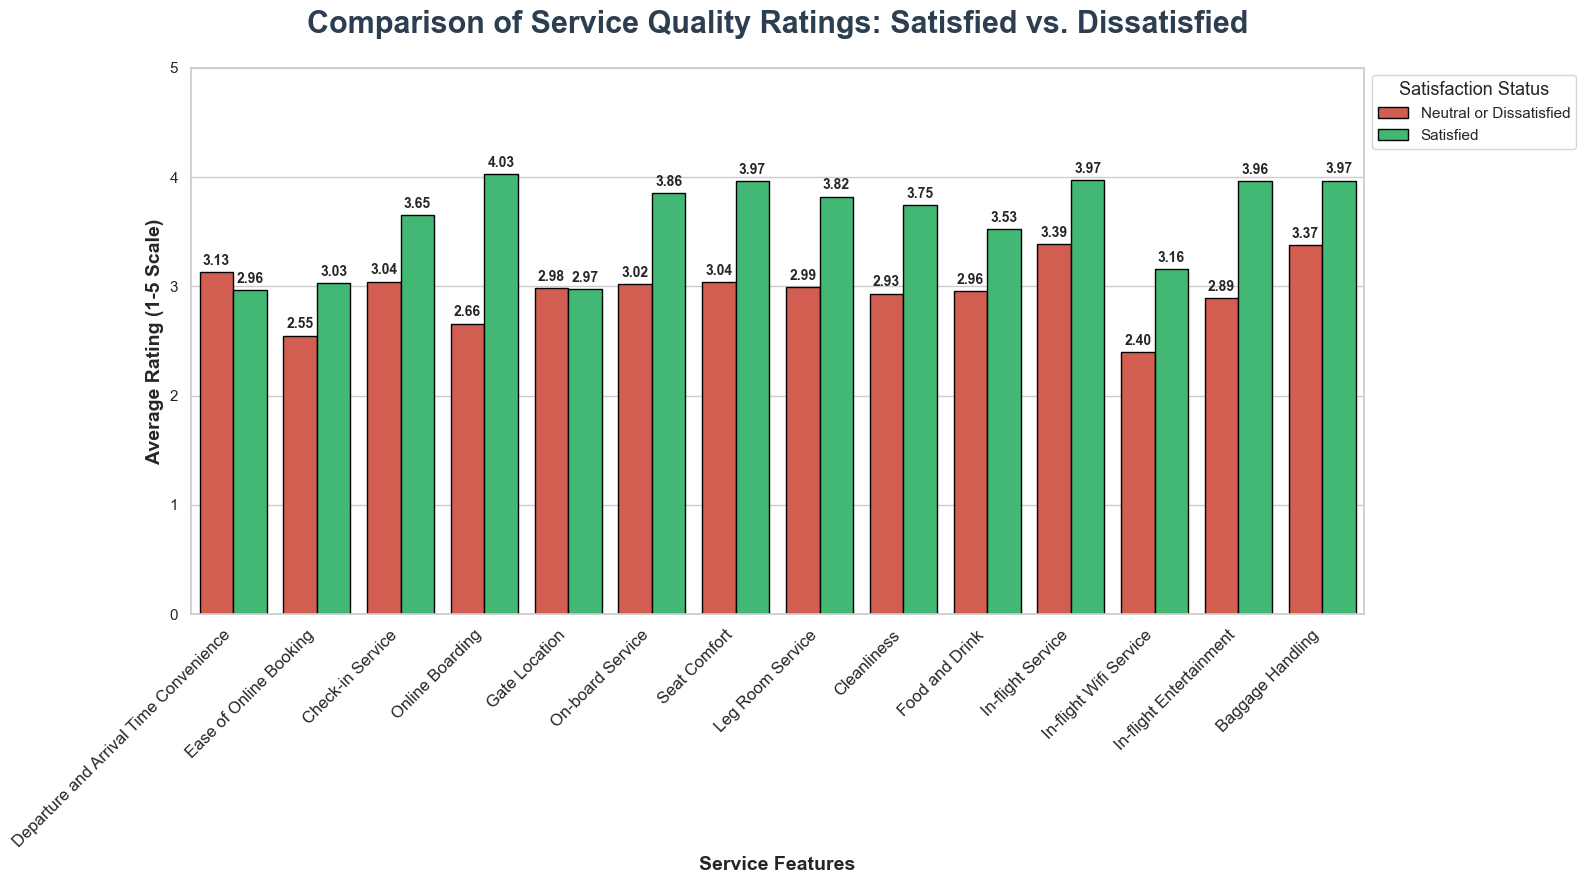

In [57]:
service_cols = [
    'Departure and Arrival Time Convenience', 'Ease of Online Booking',
    'Check-in Service', 'Online Boarding', 'Gate Location',
    'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness',
    'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
    'In-flight Entertainment', 'Baggage Handling'
]

df_grouped = df.groupby('Satisfaction')[service_cols].mean().reset_index()
df_melted = df_grouped.melt(id_vars='Satisfaction', var_name='Service', value_name='Average Rating')

plt.figure(figsize=(16, 9))
sns.set_theme(style="whitegrid")

palette = {"Satisfied": "#2ecc71", "Neutral or Dissatisfied": "#e74c3c"}

ax = sns.barplot(
    data=df_melted, 
    x='Service', 
    y='Average Rating', 
    hue='Satisfaction', 
    palette=palette,
    edgecolor='black',
    linewidth=1
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10, fontweight='bold')

plt.title('Comparison of Service Quality Ratings: Satisfied vs. Dissatisfied', 
          fontsize=22, fontweight='bold', pad=25, color='#2c3e50')
plt.xlabel('Service Features', fontsize=14, fontweight='bold')
plt.ylabel('Average Rating (1-5 Scale)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(np.arange(0, 6, 1))

plt.legend(title='Satisfaction Status', title_fontsize='13', fontsize='11', 
           loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

## Service Satisfaction Comparison Summary

#### * Satisfied passengers rate all services higher than neutral/dissatisfied passengers across every feature  

#### * Largest gaps are seen in Online Boarding, Seat Comfort, In-flight Service, In-flight Entertainment, and Baggage Handling  
#### * These features act as key drivers of overall satisfaction  

#### * In-flight Wifi Service has the lowest ratings for both groups  
#### * Indicates a common dissatisfaction area across all passengers  

#### * Ease of Online Booking and Gate Location show moderate ratings with noticeable differences  
#### * These contribute to dissatisfaction but are less critical compared to top drivers  

#### * Core services like Check-in, Cleanliness, Food, and On-board Service show smaller differences  
#### * These remain relatively stable across both groups  

#### * Overall, satisfaction is influenced by consistently higher ratings across all services  
#### * Dissatisfied passengers tend to rate every feature lower rather than a single issue

#

## Flight Distance vs Class & Satisfaction

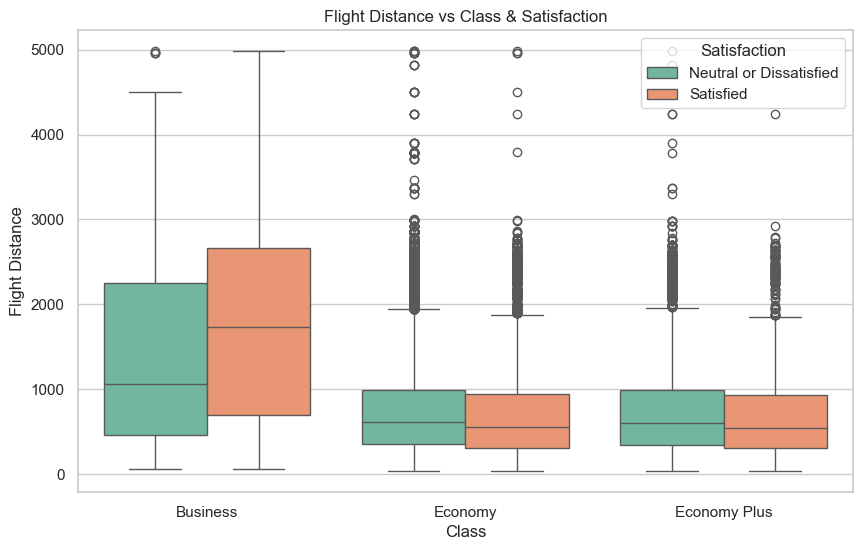

In [59]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Class', y='Flight Distance', hue='Satisfaction', data=df, palette='Set2')
plt.title('Flight Distance vs Class & Satisfaction')
plt.savefig('distance_boxplot.png')
plt.show()

### Business Class: 
* This class covers the highest average flight distance.

There is a clear distinction: Satisfied passengers in Business Class tend to travel much longer distances (median ~2,500 miles) compared to those who are Neutral or Dissatisfied.

This suggests that the premium services in Business Class are highly effective for long-haul journeys.

### Economy & Economy Plus: 
* The flight distances are significantly lower for these classes (mostly under 1,500 miles).

Interestingly, the median distance for both "Satisfied" and "Neutral/Dissatisfied" passengers is nearly the same. This indicates that for short distances, flight length isn't the main factor driving satisfaction in Economy.

### 3. Outliers Analysis
Numerous outliers are visible in the Economy and Economy Plus categories, reaching up to 4,000 miles.

Most of these long-distance outliers in Economy fall under the Neutral or Dissatisfied category, proving that Economy seats are less tolerable for very long durations.

#

# --------------------------------------------------------------------------------------

# 📊 Strategic Business Recommendations (Advanced Insights)

---

## 1. 🌐 Digital Experience & Connectivity Overhaul

**Insight:** Digital services are the primary drivers of passenger dissatisfaction.

* **Improve In-flight Wi-Fi:**
  This is the lowest-rated feature with a mean score of **2.73 / 5**, consistently underperforming across all service categories.

* **Enhance Online Booking & Gate Navigation:**

  * *Ease of Online Booking:* **2.75**
  * *Gate Location:* **2.97**
    Both fall below the average satisfaction threshold.

**Recommendation:**
Streamline the **digital interface**, improve **airport wayfinding**, and invest in **high-speed connectivity infrastructure** to elevate the passenger experience.

---

## 2. ⏱️ Operational Efficiency & Delay Management

**Insight:** While most flights are punctual, delays significantly degrade passenger satisfaction.

* **Arrival delays** have a stronger negative impact than departure delays.

**Recommendation:**

* Improve **ground handling efficiency**
* Optimize **flight paths** to recover time mid-flight
* Implement **real-time SMS updates** to proactively manage passenger expectations

---

## 3. 💼 Strategic Service Optimization by Travel Class

**Insight:** Satisfaction varies significantly by **flight duration** and **travel class**.

* Business Class satisfaction is **very high for long-haul** flights
* Drops noticeably for **short-haul routes**

**Recommendation:**
For short-haul Business Class:

* Focus on **efficiency perks** instead of full premium services

  * Priority security
  * Lounge access
  * Faster boarding

---

## 4. 🏆 Leveraging High-Performing Service Areas

**Insight:** Certain services already perform strongly and contribute to customer loyalty.

* **In-flight Service:** *3.64*
* **Baggage Handling:** *3.63*

**Recommendation:**

* Maintain excellence in these areas
* Use them as **core brand strengths**

**Target Demographics:**

* Average passenger age ≈ **39 years**
* Primary segment: **Adults**
* Opportunity: Expand engagement for **Youth** and **Senior** segments

---

## 5. 📈 Data-Driven Summary of Satisfaction Factors

**Dataset Overview:**

* Total records: **129,487**
* Mean Total Delay: ~**30 minutes**

  * Departure: **14.6 min**
  * Arrival: **15.1 min**

**Insight:**
Reducing total delay is critical for shifting passengers from **"Neutral/Dissatisfied" → "Satisfied"**.

**Physical Comfort Analysis:**

* **Seat Comfort:** *3.44*
* **Cleanliness:** *3.29*

These are relatively stable, indicating:

* Physical environment is **acceptable**
* Functional services (Wi-Fi, booking, delays) require **urgent improvement**

---
